In [6]:
import flopy
import numpy as np
import matplotlib.pyplot as plt
import os
import xmf6
from gwf_model_1 import build

In [7]:
# --- Datos para la configuración de la simulación --- 
# Opciones de SO's: linux, macos, macosarm, windows
conf = {
    'mf6_exe' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
    'model_name' : "flow",
    'sim_ws' : "sandbox3"
}

# --- Datos para la discretización temporal ---
time = {
    'units': "DAYS",
    'nper' : 1,
    'perioddata': [(1.0, 1, 1.0)]
}

# --- Datos para la discretización espacial ---
mesh = {
    'nlay': 1, 
    'nrow': 20, 
    'ncol': 30,
    'delr': 0.5, 
    'delc': 0.5, 
    'top' : 0.0, 
    'botm': -1.0 
}

# --- Datos para las condiciones iniciales ---
ic_data = {
    'strt': 10
}

# --- Datos para las condiciones de frontera ---
chd_data = []
for row in range(mesh['nrow']):
    chd_data.append([(0, row, 0), 10.0])       # Condición en la pared izquierda
    chd_data.append([(0, row, mesh['ncol'] - 1), 5.0]) # Condición en la pared derecha

# --- Datos para las propiedades de flujo ---
# Creamos un arreglo de conductividad hidráulica para toda la grilla
k_data = np.random.rand(mesh['nlay'], mesh['nrow'], mesh['ncol'])*0.01  # Inicializamos con 1.0
    
# Asignamos una conductividad baja en una sección del dominio
k_data[:,7:17,7:17] = 0.01  # columnas 5 a 9

# --- Construcción de la simulación y del modelo GWF ---
o_sim, o_gwf = build(conf, time, mesh, ic_data, chd_data, k_data)

# --- Escribimos los archivos ---
o_sim.write_simulation()

In [9]:
# --- ejecutamos la simulación ---
o_sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ..\..\..\..\mf6\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Go

(True, [])

In [11]:
### --- Recuperación de la carga hidráulica ---

# construimos el nombre con la ruta y extensión correcta
headfile = os.path.join(f"{conf["sim_ws"]}", f"{conf["model_name"]}.hds")

# Objeto para obtener y manipular arreglos o series de tiempo de arreglos con datos
# de una o más celdas con información del archivo binario de la carga hidráulica.
hds = flopy.utils.HeadFile(headfile)

# Solo se obtiene la capa 0, cuando no se pone ningún valor en el parámetro mlay se obtienen todas las capas
head = hds.get_data(mflay=0)

### --- Recuperación de la descarga específica ---

# construimos el nombre con la ruta y extensión correcta
budfile = os.path.join(f"{conf["sim_ws"]}", f"{conf["model_name"]}.bud")

# Objeto para obtener y manipular arreglos o series de tiempo de arreglos con datos
# de una o más celdas con información del archivo binario del budget.
bud  = flopy.utils.CellBudgetFile(budfile)

# Cargar resultados de la descarga específica
spdis = bud.get_data(text="DATA-SPDIS")[0]

# Extraer componentes del flujo en un arreglo 3D para graficación
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, o_gwf)

# --- Coordenadas del centro de celdas para graficación ---

x, y, z = o_gwf.modelgrid.xyzcellcenters

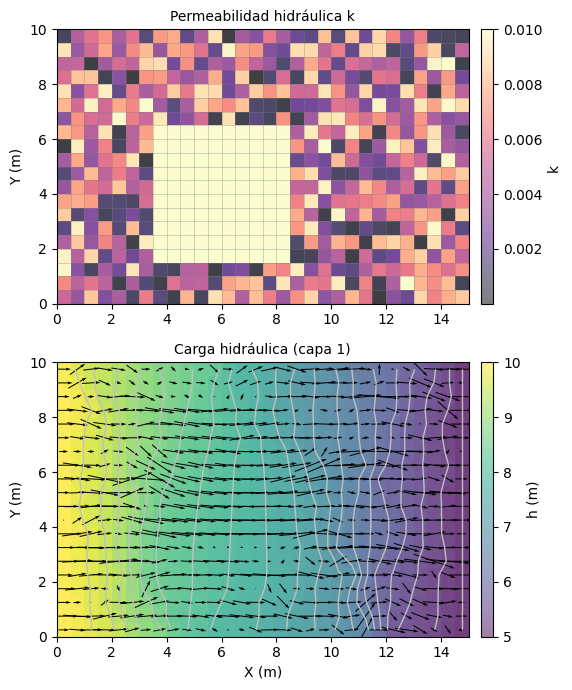

In [12]:
fig, ax = plt.subplots(2, 1, figsize =(6,7))

# Datos de la permeabilidad hidráulica.
k_mapview = flopy.plot.PlotMapView(model=o_gwf, ax=ax[0])

# Visualización de la malla, con una transparencia.
k_mapview.plot_grid(linewidths=0.5, alpha =0.5)

# Visualización de la carga hidráulica usando un mapa de color.
k_cb = k_mapview.plot_array(k_data, cmap="magma", vmin=np.nanmin(k_data), vmax=np.nanmax(k_data), alpha=0.5)

# Barra de color.
plt.colorbar(k_cb, ax=ax[0], label="k ", cax = xmf6.vis.cax(ax[0], k_cb))

# Personalización de la gráfica.
ax[0].set_title("Permeabilidad hidráulica k", fontsize=10)
ax[0].set_ylabel("Y (m)")
ax[0].set_aspect('equal')

# Mapa visual del modelo. En este caso el modelo es 'o_gwf'.
mapview = flopy.plot.PlotMapView(model=o_gwf, ax=ax[1])

# Visualización de la carga hidráulica usando un mapa de color.
cb = mapview.plot_array(head, cmap="viridis", vmin=np.nanmin(head), vmax=np.nanmax(head), alpha=0.5)

# Visualización de la carga hidráulica usando contornos.
ct = mapview.contour_array(head, levels=20, linewidths=1.0, colors='silver')

# Graficar los vectores de flujo
skip = (slice(None, None, 1), slice(None, None, 1))  # Saltar para no saturar
ax[1].quiver(x, y[::-1], qx[0], qy[0][::-1], scale=0.03, linewidth =0.15, color='k', pivot='middle')
#ax[2].streamplot(x, y[::-1][:], qx[0], qy[0][::-1], color='k', linewidth=0.5)
#ax[2].yaxis.set_inverted(True)
#ax[2].set_aspect('equal')

# Barra de color.
plt.colorbar(cb, ax=ax[1], label="h (m)", cax = xmf6.vis.cax(ax[1], cb))

# Personalización de la gráfica.
ax[1].set_title("Carga hidráulica (capa 1)", fontsize=10)
ax[1].set_xlabel("X (m)")
ax[1].set_ylabel("Y (m)")
ax[1].set_aspect('equal')

plt.tight_layout()
plt.show()